# Pedotransfer Functions and the Retention Curve

**MOOC "The Hydrology of Soil" — Chapter 5, Episode 05x01**
*Companion notebook — pedotransfer functions (PTFs)*

---

A **pedotransfer function** estimates the *hydraulic* parameters of a soil — the
ones that close Richards' equation — from *cheap, easily measured* properties:
texture (sand / silt / clay), and optionally bulk density and water contents.
The term is due to **Bouma (1989)**.

This notebook lets you:

1. enter a soil **texture** and obtain, via the **Rosetta** PTF
   (Zhang & Schaap, 2017), the **van Genuchten** parameters
   $\theta_r,\ \theta_s,\ \alpha,\ n,\ K_s$;
2. **draw the resulting retention curve** $\theta(\psi)$ and the unsaturated
   conductivity $K(\theta)$;
3. **compare several soils** on the same axes, and see the **uncertainty**
   that the PTF itself reports.

It connects Chapter 1 (texture) to Chapter 2 (the retention curve) and
Chapter 3 (hydraulic conductivity): one texture triple → a full set of
constitutive relations.

## 0 — Setup

In [2]:
!pip install rosetta-soil

try:
    from soil_course import *
    print("soil_course already available")
except ModuleNotFoundError:
    !pip install git+https://github.com/panzerotto/soil_course.git
    from soil_course import *

print("Setup complete")

soil_course already available
Setup complete


## 1 — From texture to van Genuchten parameters

`rosetta` takes a list of `[sand%, silt%, clay%]` triples and returns, for each,
the parameters of the **van Genuchten–Mualem** model:

$$S_e(\psi)=\big[1+(\alpha|\psi|)^{n}\big]^{-m},\quad m=1-\tfrac1n,
\qquad \theta=\theta_r+(\theta_s-\theta_r)\,S_e .$$

Rosetta returns 7 numbers per soil; we use the first five:
$\theta_r,\ \theta_s,\ \alpha\,[\text{cm}^{-1}],\ n,\ K_s\,[\text{cm/day}]$.
It also returns a **bootstrap standard deviation** for each — the PTF's own
estimate of how uncertain it is.


In [3]:
# Example Rosetta estimates for common textures
print_rosetta_examples()


Sand         theta_r=0.052  theta_s=0.367  alpha=0.0311 1/cm  n=2.640  Ks=490.6 cm/day
Loam         theta_r=0.089  theta_s=0.404  alpha=0.0068 1/cm  n=1.419  Ks=12.8 cm/day
Silt loam    theta_r=0.090  theta_s=0.430  alpha=0.0038 1/cm  n=1.499  Ks=15.9 cm/day
Clay         theta_r=0.130  theta_s=0.486  alpha=0.0135 1/cm  n=1.243  Ks=20.9 cm/day


{'Sand': {'theta_r': np.float64(0.05211911173222768),
  'theta_s': np.float64(0.36672213816496424),
  'alpha': np.float64(0.0311454949220733),
  'n': np.float64(2.6402881160213254),
  'Ks': np.float64(490.5738649379545),
  'theta_r_sd': np.float64(0.003078413021153446),
  'theta_s_sd': np.float64(0.003976798140754312),
  'alpha_sd': np.float64(0.0020943975807412325),
  'n_sd': np.float64(0.1176199656930406),
  'Ks_sd': np.float64(63.531072356524184),
  'model_code': 2},
 'Loam': {'theta_r': np.float64(0.08865862832320667),
  'theta_s': np.float64(0.40401701913250276),
  'alpha': np.float64(0.006766451696570648),
  'n': np.float64(1.4193374497295332),
  'Ks': np.float64(12.767568244611063),
  'theta_r_sd': np.float64(0.005975503958470785),
  'theta_s_sd': np.float64(0.0071694383272999235),
  'alpha_sd': np.float64(0.00112456975979685),
  'n_sd': np.float64(0.04192316254554983),
  'Ks_sd': np.float64(3.0794650410401654),
  'model_code': 2},
 'Silt loam': {'theta_r': np.float64(0.08994502

## 2 — The van Genuchten retention and conductivity curves

Given the parameters, the retention curve and the **Mualem** conductivity are

$$\theta(\psi)=\theta_r+(\theta_s-\theta_r)\big[1+(\alpha|\psi|)^n\big]^{-m},$$

$$K(S_e)=K_s\,S_e^{\,\ell}\Big[1-\big(1-S_e^{1/m}\big)^{m}\Big]^{2},
\qquad \ell=0.5 .$$


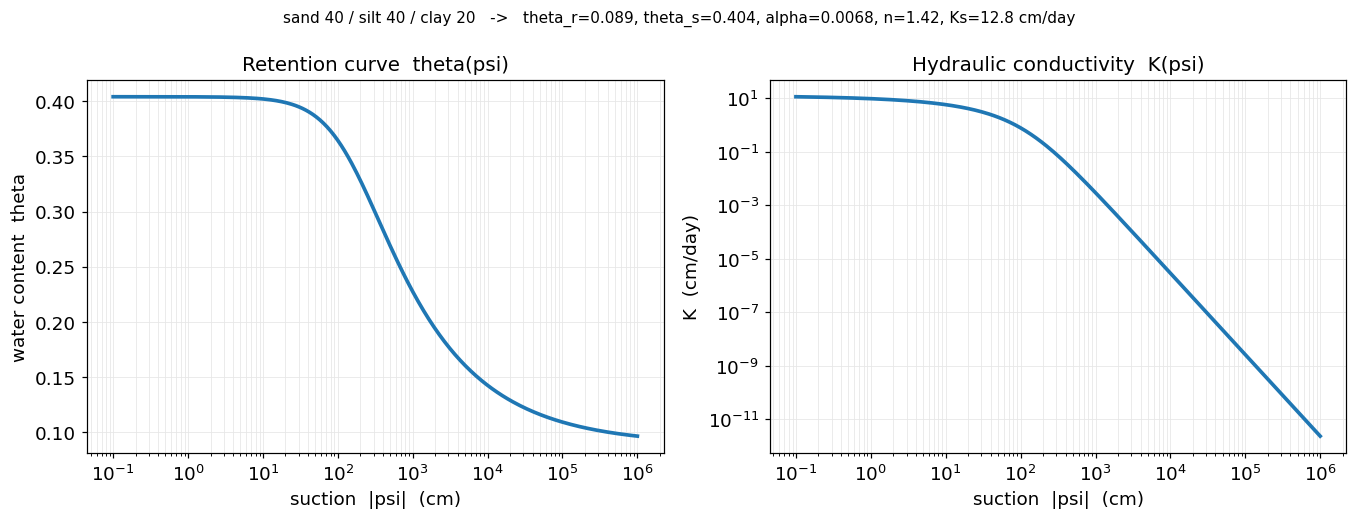

{'theta_r': np.float64(0.08865862832320667),
 'theta_s': np.float64(0.40401701913250276),
 'alpha': np.float64(0.006766451696570648),
 'n': np.float64(1.4193374497295332),
 'Ks': np.float64(12.767568244611063),
 'theta_r_sd': np.float64(0.005975503958470785),
 'theta_s_sd': np.float64(0.0071694383272999235),
 'alpha_sd': np.float64(0.00112456975979685),
 'n_sd': np.float64(0.04192316254554983),
 'Ks_sd': np.float64(3.0794650410401654),
 'model_code': 2}

In [4]:
# Draw retention and conductivity curves for one soil
plot_pedotransfer_soil(sand=40, silt=40, clay=20)   # a loam


### 2.1 — Interactive: texture sliders

Move the **sand** and **clay** sliders (silt is the remainder). The two curves
redraw, and the predicted parameters appear in the title.


In [5]:
# Interactive texture sliders
interactive_pedotransfer_soil()


interactive(children=(FloatSlider(value=40.0, continuous_update=False, description='sand %', step=1.0), FloatS…

interactive(children=(FloatSlider(value=40.0, continuous_update=False, description='sand %', step=1.0), FloatS…

## 3 — Comparing soils, and the uncertainty of the PTF

Two things worth seeing directly.

**(a) Texture controls the shape.** Sand drains at low suction (steep curve
near saturation); clay holds water to very high suction. Plot them together.

**(b) A PTF is an estimate, not a measurement.** Rosetta returns a bootstrap
standard deviation for every parameter. The band below shows the retention
curve recomputed with $n$ and $\alpha$ shifted by $\pm 1$ standard deviation —
a visual reminder that the curve a PTF gives you is uncertain, sometimes
substantially so. This is exactly the **Weber et al. (2023)** caution from
the slides: a PTF must be used within the population it was trained on.


In [ ]:
# Compare textures and show PTF uncertainty
compare_pedotransfer_soils([
    ("Sand",      92, 5, 3),
    ("Loam",      40, 40, 20),
    ("Silt loam", 20, 60, 20),
    ("Clay",      20, 20, 60),
])

plot_pedotransfer_uncertainty(sand=20, silt=20, clay=60)   # clay: often very uncertain


## Exercises

1. **The drainage clock.** Compare a sand and a clay. At suction = 100 cm
   (about field capacity), read off $\theta$ for each. Which soil still holds
   most of its water, and why?

2. **Texture vs structure — again.** Rosetta sees only texture. Take a clay
   and note its $K_s$. Slide 12 of Chapter 1 showed that real clay has a
   *bimodal* pore structure with large inter-aggregate pores. Would you expect
   the field $K_s$ of a structured clay to be **higher or lower** than
   Rosetta's texture-only estimate? Explain.

3. **How much can you trust it?** Use `plot_with_uncertainty` for a sand, a
   loam and a clay. For which texture is the PTF band widest? Relate your
   answer to the Weber et al. (2023) warning that PTFs extrapolate poorly.

4. **Closing Chapter 1 → 2.** Take the `(sand, clay)` of a soil you classified
   on the texture triangle in the Chapter 1 notebook, run it here, and report
   its retention curve. You have now gone from a *named soil* to a *constitutive
   law* for Richards' equation.

---
*Companion to the MOOC "The Hydrology of Soil", Episode 05x01. CC BY-SA.
Rosetta PTF: Zhang & Schaap (2017), J. Hydrology; package `rosetta-soil`.*
